In [1]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from scipy.stats import shapiro, kstest, probplot
from statsmodels.graphics.gofplots import qqplot

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df_pontuacao = pd.read_csv('dados.csv')
# df_pontuacao.head()
df_pontuacao.describe()

,horas_estudo,pontuacao_teste
count,101.000000,101.000000
mean,28.604950,455.000000
std,14.116128,221.385411
min,1.100000,30.000000
25%,16.500000,270.000000
50%,30.900000,465.000000
75%,41.800000,655.000000
max,46.900000,800.000000


<Axes: xlabel='horas_estudo', ylabel='pontuacao_teste'>

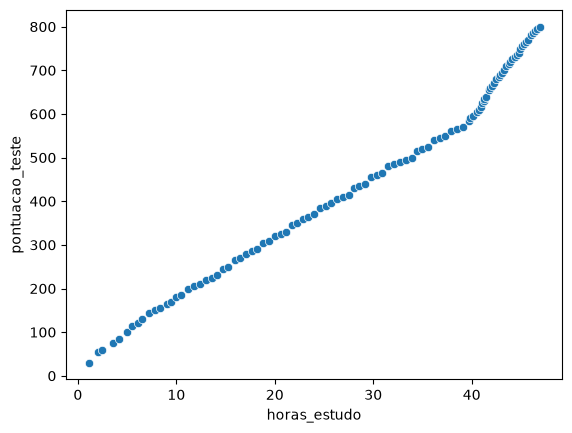

In [7]:
sns.scatterplot(data=df_pontuacao, x='horas_estudo', y='pontuacao_teste')

<Axes: ylabel='horas_estudo'>

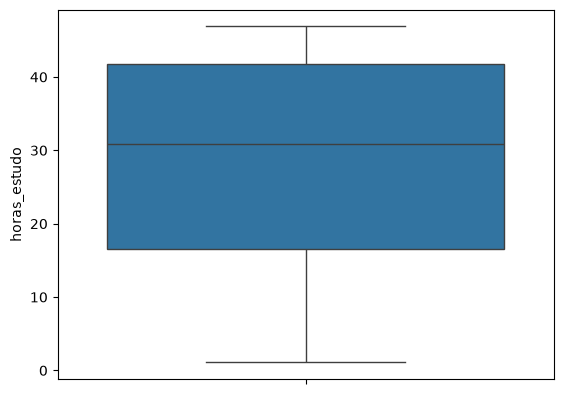

In [11]:
sns.boxplot(df_pontuacao, y='horas_estudo')

<Axes: ylabel='pontuacao_teste'>

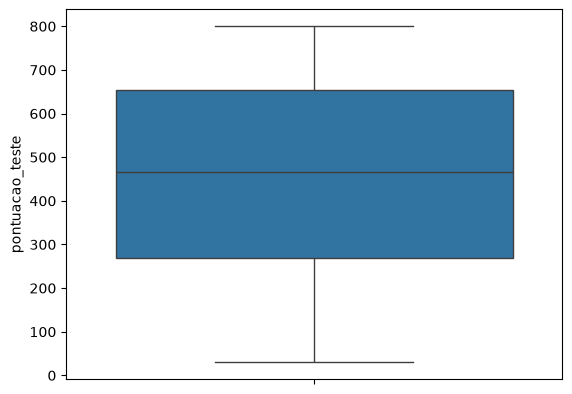

In [10]:
sns.boxplot(df_pontuacao, y='pontuacao_teste')

<Axes: >

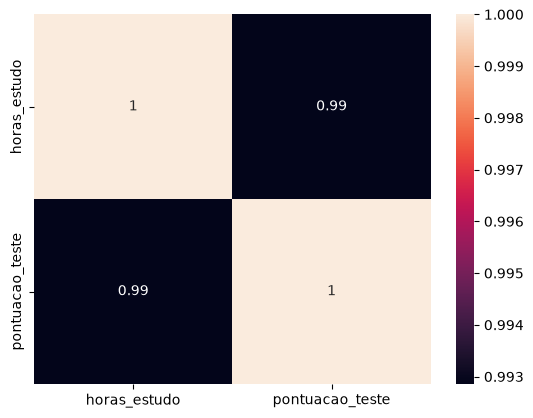

In [12]:
sns.heatmap(df_pontuacao.corr('pearson'), annot=True)

<Axes: >

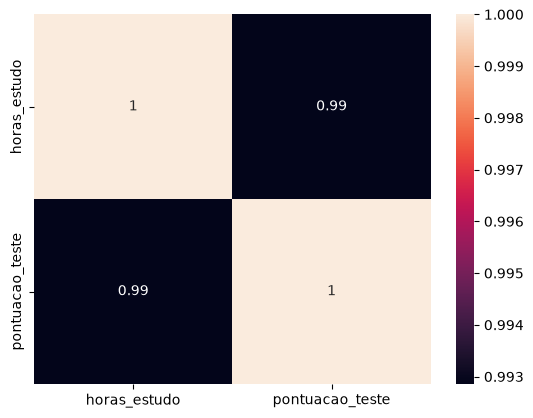

In [ ]:
sns.heatmap(df_pontuacao.corr('pearson'), annot=True)
#ve a relacao linear, se quando sobe ambas sobem ou descem quando descem de forma constante em linha reta

<Axes: >

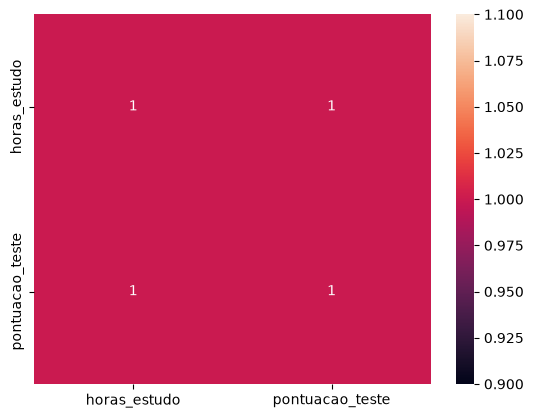

In [ ]:
sns.heatmap(df_pontuacao.corr('spearman'), annot=True) #se sobem junto ou descem juntos, nem que seja linha reta

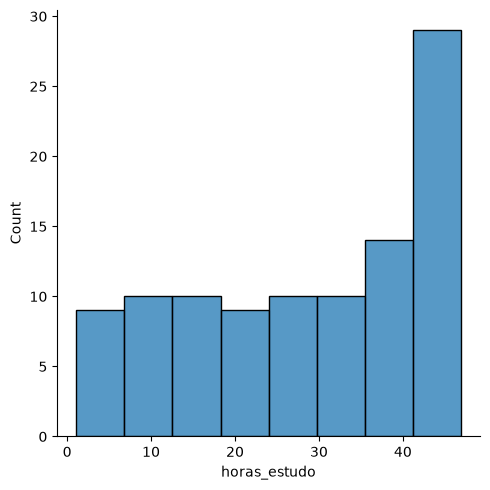

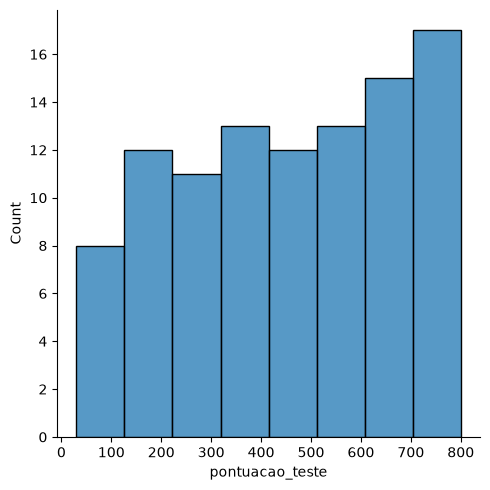

In [16]:
#histograma
sns.displot(df_pontuacao, x='horas_estudo')
sns.displot(df_pontuacao, x='pontuacao_teste')

In [25]:
x = df_pontuacao['horas_estudo'].values.reshape(-1,1)
y = df_pontuacao['pontuacao_teste'].values.reshape(-1,1)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=30, random_state=50)

In [26]:
reg_model = LinearRegression()

In [27]:
reg_model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[15.62]]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[9.22]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[120.54]


In [31]:
y_pred = reg_model.predict(x_test)
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
r2_score(y_test, y_pred)

0.9819595227741714

In [34]:
# Calcular a métrica MAE (Mean Absolute Error)
# MAE = Media (y_test - y_pred)
# É uma métrica fácil de interpretar
# MAE é menos sensível a outliers

mean_absolute_error(y_test, y_pred)

23.170976069374593

In [33]:
# Calcular a métrica MSE (Mean Squared Error)
# MSE = Média (y_test - y_pred)2
# Não é uma mátrica fácil de interpretar
# MAE é mais sensível a outliers e penaliza grandes erros

mean_squared_error(y_test, y_pred)

785.9634578052633

In [42]:
#validando
y_pred = reg_model.predict(x_test)
r2_score(y_test, y_pred)
mean_absolute_error(y_test, y_pred)

23.170976069374593

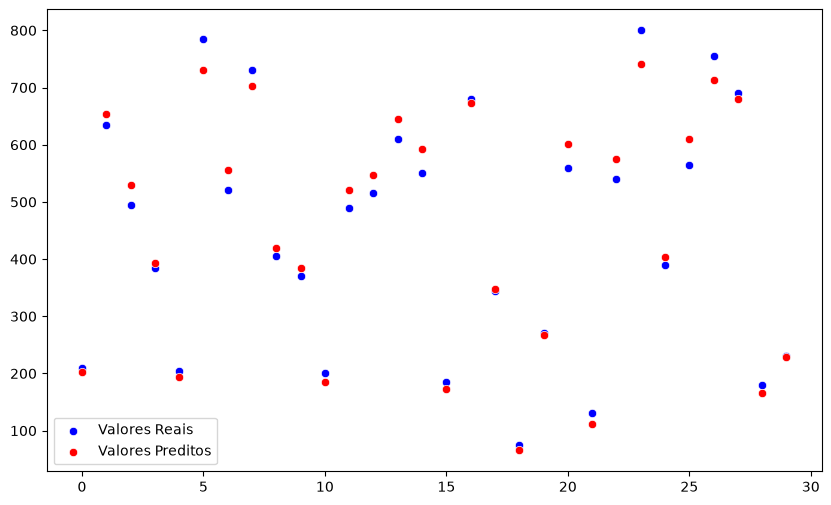

In [43]:
x_axis = range(len(y_test))
plt.figure(figsize=(10,6))
sns.scatterplot(x=x_axis, y=y_test.reshape(-1), color='blue', label='Valores Reais')
sns.scatterplot(x=x_axis, y=y_pred.reshape(-1), color='red', label='Valores Preditos')
plt.legend()

In [46]:
residuos = y_test-y_pred
#standardization (calcular residuos padronizados)

from scipy.stats import zscore
residuos_std = zscore(residuos)

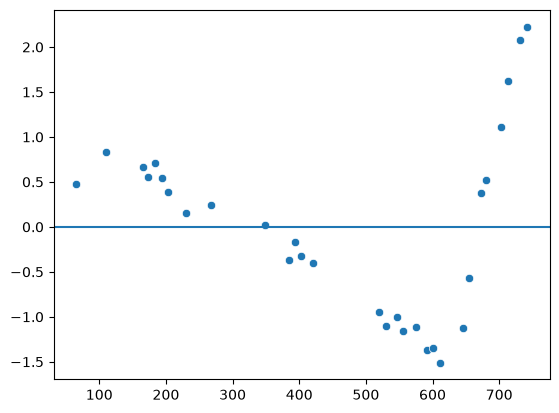

In [47]:
#linearidade
#se tiver entre -2 e 2 indica linearidade
#homogeniedade das variancias. se tiver em torno da reta é homocedascidade, se tiver tendencia forma cone funil etc...

sns.scatterplot(x=y_pred.reshape(-1),y=residuos_std.reshape(-1))
plt.axhline(y=0)

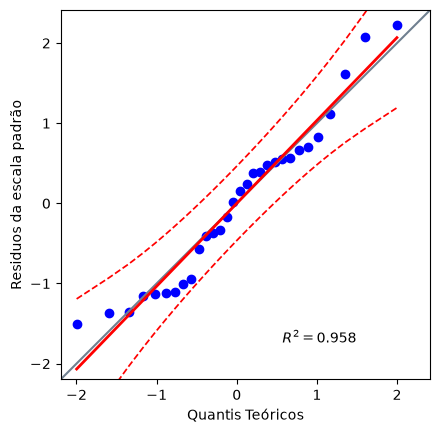

In [49]:
import pingouin as pg
pg.qqplot(residuos_std, dist='norm', confidence=0.95)
plt.xlabel('Quantis Teóricos')
plt.ylabel('Residuos da escala padrão')
plt.show()

In [50]:
# Teste de Normalidade - Shapiro Wilk
# H0 - Segue distribuição normal
# H1 - Não segue distribução normal 
# Se o p-valor > 0.5 não rejeita H0, caso contrário rejeitamos

stat_shapiro, p_valor_shapiro = shapiro(residuos.reshape(-1))
print(f"Estatística do teste: {stat_shapiro} e P-Valor: {p_valor_shapiro}")

Estatística do teste: 0.9488182621820983 e P-Valor: 0.15716280615499917


In [51]:
# Teste de Normalidade - Kolmogorov-Sminorv
# H0 - Segue distribuição normal
# H1 - Não segue distribução normal 
# Se o p-valor > 0.5 não rejeita H0, caso contrário rejeitamos

stat_ks, p_valor_ks = kstest(residuos.reshape(-1), 'norm')
print(f"Estatística do teste: {stat_ks} e P-Valor: {p_valor_ks}")

Estatística do teste: 0.4994312223623084 e P-Valor: 1.9201934242505674e-07
